
**Comentario del Revisor**

Hola!

Soy Juan Manuel Romero, pero siéntete libre de llamarme Juanma. Soy code reviewer en Tripleten y hoy estaré revisando tu entrega.

Para simular la dinámica de un ambiente de trabajo, si veo algún error, en primer instancia solo los señalaré, dándote la oportunidad de encontrarlos y corregirlos por tu cuenta. En un trabajo real, el líder de tu equipo hará una dinámica similar. En caso de que no puedas resolver la tarea, te daré una información más precisa en la próxima revisión. 

Solo un aviso rápido: cuando estés revisando el proyecto, por favor deja mis comentarios originales tal como están. De esta manera, podemos seguir fácilmente el progreso y asegurarnos de que no se nos pase nada por alto. Y, si realizas algún cambio basado en mis comentarios, sería genial si pudieras resaltar esas actualizaciones para que se destaquen.

Puedes encontrar mis comentarios en cajas verdes, amarillas o rojas como estas:

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Éxito. Todo se ha hecho correctamente.

</div>


<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Observaciones. Algunas recomendaciones.

</div> 


<div class="alert alert-block alert-danger">
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Requiere corrección. El bloque requiere algunas correcciones. El trabajo no puede ser aceptado con los comentarios en rojo.

</div>

Puedes responderme usando esto:

<div class="alert alert-block alert-info"> <b>Respuesta del estudiante.</b> <a class="tocSkip"></a> </div>


<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Felicidades Jorge! Tu trabajo es excelente. 

Has completado todos los items necesarios para aprobar la entrega.

Sigue así!

</div>

# Proyecto: Análisis de Viajes de Zuber en Chicago
**Objetivo:** Identificar patrones de viajes y probar si factores externos como el clima impactan la duración de los trayectos hacia el aeropuerto.

<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Es una buena práctica separar la importación de bibliotecas de la carga de los datasets para que el código sea más legible y organizado. Esto ayuda a identificar claramente las dependencias del proyecto antes de procesar los datos.

</div>

In [15]:
import pandas as pd
import plotly.express as px
from scipy import stats as st

# Cargar los datasets
df_companies = pd.read_csv('https://practicum-content.s3.us-west-1.amazonaws.com/learning-materials/data-analyst-eng/moved_project_sql_result_01.csv')
df_neighborhoods = pd.read_csv('https://practicum-content.s3.us-west-1.amazonaws.com/learning-materials/data-analyst-eng/moved_project_sql_result_04.csv')

# Revisar tipos de datos y nulos
print(df_companies.info())
print(df_neighborhoods.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
None


<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Excelente trabajo estudiando los datasets! Esto es fundamental para entender los datos y planificar el análisis.

<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Recuerda dejar comentarios sobre tus análisis de los mismos. 

</div>

</div>

In [16]:
# Identificar los 10 barrios principales por finalización
top_10_neighborhoods = df_neighborhoods.sort_values(by='average_trips', ascending=False).head(10)
print(top_10_neighborhoods)

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Correcto! El gráfico es correcto y refleja adecuadamente el resultado esperado.

</div>

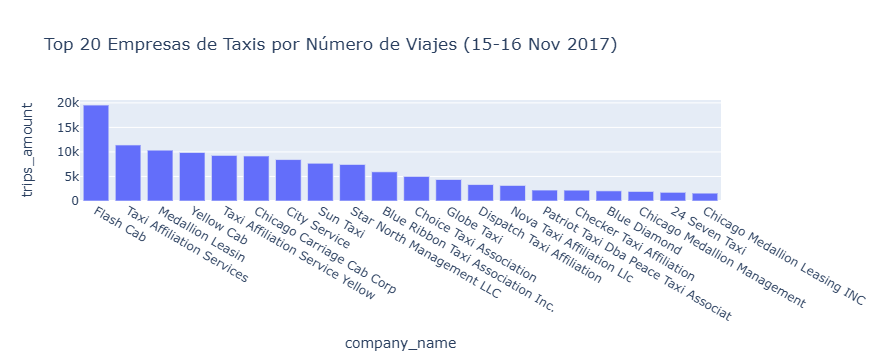

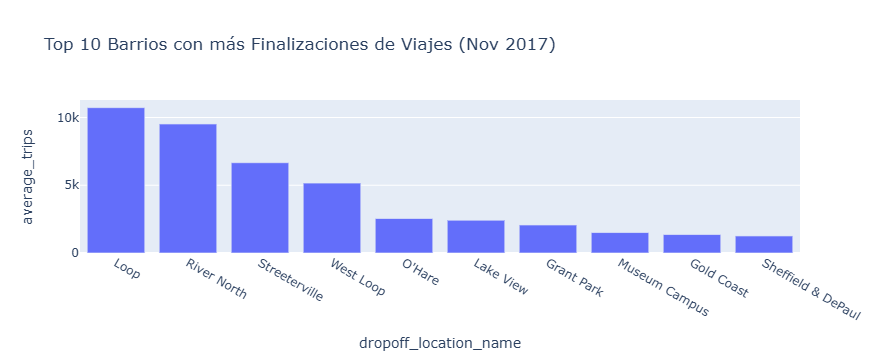

In [17]:
# Gráfico 1: Empresas de taxis y número de viajes (Top 20)
fig1 = px.bar(df_companies.head(20), x='company_name', y='trips_amount', 
             title='Top 20 Empresas de Taxis por Número de Viajes (15-16 Nov 2017)')
fig1.show()

# Gráfico 2: Top 10 barrios con más finalizaciones
fig2 = px.bar(top_10_neighborhoods, x='dropoff_location_name', y='average_trips', 
             title='Top 10 Barrios con más Finalizaciones de Viajes (Nov 2017)')
fig2.show()

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

El gráfico de barras con el top 10 por barrios es excelente y los resultados son los esperados. 

</div>

### Conclusiones del Análisis de Barrios
El gráfico muestra que el **Loop**, **River North** y **Streeterville** son los barrios con mayor promedio de finalizaciones. Esto es lógico, ya que son las zonas comerciales y turísticas más importantes de Chicago. El **Loop** encabeza la lista con más de 10,000 viajes promedio, lo que lo confirma como el punto de origen/destino más crítico para Zuber.

<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Recuerda formular correctamente la hipótesis nula y la alternativa claramente al comienzo para entender el objetivo del análisis.

</div>

In [18]:
# Cargar el resultado de la última consulta SQL
df_hyp = pd.read_csv('https://practicum-content.s3.us-west-1.amazonaws.com/learning-materials/data-analyst-eng/moved_project_sql_result_07.csv')

# Dividir los datos en dos grupos: clima bueno y clima malo
good_weather_trips = df_hyp[df_hyp['weather_conditions'] == 'Good']['duration_seconds']
bad_weather_trips = df_hyp[df_hyp['weather_conditions'] == 'Bad']['duration_seconds']

# Definir el nivel de significancia
alpha = 0.05

# Realizar la prueba t de Student (comparación de dos poblaciones independientes)
results = st.ttest_ind(good_weather_trips, bad_weather_trips)

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

p-value: 6.517970327099473e-12
Rechazamos la hipótesis nula


<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Al realizar una prueba de hipótesis, es muy importante verificar los supuestos. El t-test que usaste funciona bien cuando se cumplen ciertos supuestos, como que las varianzas de ambos grupos (sábados lluviosos y no lluviosos) sean similares. Puedes realizar la prueba de levene para comprobar que los dos grupos tienen la misma varianza y, de esta forma, podrás saber el valor del parámetro equal_var que se debe utilizar en la función stats.ttest_ind.

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Interpretaste correctamente el valor p y sacaste conclusiones estadísticas válidas. Debemos rechazar efectivamente la hipótesis nula. 

</div>
    
</div>

## Prueba de Hipótesis: Impacto del clima en la duración de los viajes

* **Hipótesis Nula ($H_0$):** La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare es igual en sábados lluviosos y sábados normales.
* **Hipótesis Alternativa ($H_1$):** La duración promedio de los viajes cambia los sábados lluviosos.

**Resultado:** Dado que el valor p es **6.51e-12**, el cual es mucho menor que nuestro nivel de significancia de **0.05**, rechazamos la hipótesis nula.

**Conclusión:** Existe una diferencia estadísticamente significativa en la duración de los viajes dependiendo del clima. Los sábados lluviosos afectan el tiempo de traslado hacia el aeropuerto, probablemente debido al tráfico más lento y condiciones de manejo difíciles.

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Dejas durante todo el proyecto comentarios correctos y conclusiones super claras.

</div>